In [2]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt 
import os 

from tensorflow.keras.preprocessing.text import Tokenizer 
from tensorflow.keras.layers import Embedding 
from tensorflow.keras.preprocessing.sequence import pad_sequences

2023-07-05 16:22:38.699322: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-07-05 16:22:38.945076: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-07-05 16:22:38.948172: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-05 16:22:39.855822: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


# 1. Positional Encoding 
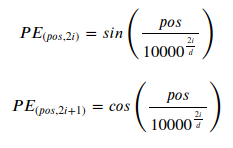

In [3]:
def position_encoding(position, d): 
    angles= np.arange(position)[:, np.newaxis]/ np.power(10000, (np.arange(d)[np.newaxis,:]//2 /np.float(d)))
    angles[:,0::2]= np.sin(angles[:,0::2])
    angles[:, 1::2]= np.cos(angles[:, 1::2])
    
    pos_encoding= angles[np.newaxis,...]
    
    return tf.cast(pos_encoding, dtype= tf.float32)

/tmp/ipykernel_6192/1792230233.py:2: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  angles= np.arange(position)[:, np.newaxis]/ np.power(10000, (np.arange(d)[np.newaxis,:]//2 /np.float(d)))
2023-07-05 16:22:41.281172: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-07-05 16:22:41.281714: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the m

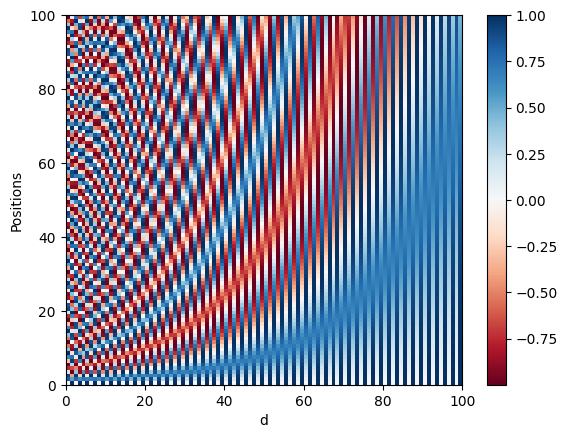

In [4]:
embedding_dim= 100
max_seq_len= 100 
max_words= 64
pos_encoding= position_encoding(max_seq_len, embedding_dim)

plt.pcolormesh(pos_encoding[0], cmap="RdBu")
plt.xlabel("d")
plt.ylabel("Positions")
plt.xlim(0,embedding_dim)
plt.colorbar() 
plt.show() 

## Positional encoding visualization 
#### 1. The eucleadean norm of the element is always equal no matter the position 
#### 2. The norm of difference of the two elements seperated by k position is also always equal 
#### Lets verify this. 


In [7]:
k = 5 
print(f"The norm of the 10th element is {tf.norm(pos_encoding[0, 10, :])}")
print(f"The norm of the 20th element is {tf.norm(pos_encoding[0, 20, :])}")

print(f"The norm of the difference between 25th and 25+k th element is {tf.norm(pos_encoding[0,25,:] - pos_encoding[0,25+k,:])}")
print(f"The norm of the difference between 26th and 26-k th element is {tf.norm(pos_encoding[0,26,:] - pos_encoding[0,26-k,:])}")

The norm of the 10th element is 7.071067810058594
The norm of the 20th element is 7.071067810058594
The norm of the difference between 25th and 25+k th element is 7.227489471435547
The norm of the difference between 26th and 26-k th element is 7.227489471435547


## Comparing position encoding 
#### Correlation - Calculating the correlation between the pairs of vector helps to illustrate how these vector represents the relative position of the word. A good position encoder produces will produce a perfectly symmetric matrix where the maximum correlation values are located in the diagonal and the corr values decreases as we move away from the main diagonal.  


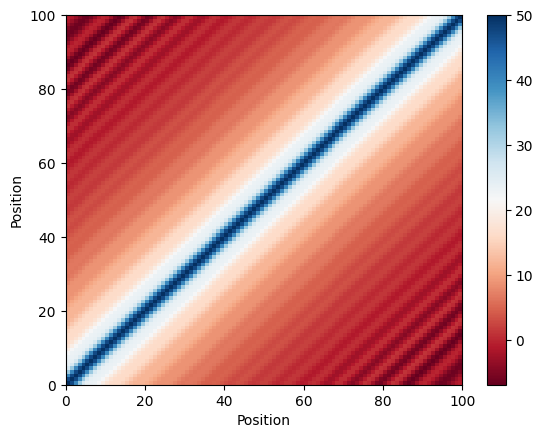

In [8]:
corr= tf.matmul(pos_encoding, pos_encoding, transpose_b= True).numpy()[0]
plt.pcolormesh(corr, cmap= "RdBu")
plt.xlabel("Position")
plt.ylabel("Position")
plt.colorbar() 
plt.xlim(0, max_seq_len)
plt.show()

#### Euclidean Distance - The euclidean distance also helps us to compare the positional encoding vectors. In this case, the visualization should result in 0 in main diagonals and values keep decreasing as we move away from the diagonals. 

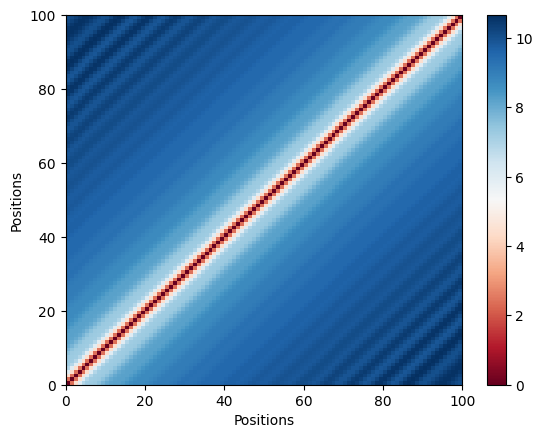

In [10]:
eu= np.zeros((max_seq_len, max_seq_len))
for a in range(max_seq_len): 
    for b in range(a+1, max_seq_len): 
        eu[a,b]= tf.norm(tf.subtract(pos_encoding[0,a], pos_encoding[0,b]))
        eu[b,a]= eu[a,b]
        
plt.pcolormesh(eu, cmap= "RdBu")
plt.xlabel("Positions")
plt.ylabel("Positions")
plt.xlim(0, max_seq_len)
plt.colorbar()
plt.show()

### After this we calculate the embedding or load the pre-existing embedding then add the positional encoding to the embedding which helps to visualize the sentences more efficiently. 